import os
from matplotlib import pyplot as plt
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Load data

In [20]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2,contrast = 0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485,0.456,0.406],std = [0.229,0.214,0.225])
    
]
    
)

In [21]:
dataset_path = './dataset'
dataset = datasets.ImageFolder(root = dataset_path,transform = image_transform)
len(dataset)

2300

In [22]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [23]:
num_classes = len(dataset.classes)
num_classes

6

In [25]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size,val_size

(1725, 575)

In [26]:
from torch.utils.data import random_split
train_datset,val_dataset = random_split(dataset,[train_size,val_size])

In [29]:
train_loader = DataLoader(train_datset,batch_size = 32 ,shuffle = True)
val_loader = DataLoader(val_dataset,batch_size = 32 ,shuffle = True)

In [30]:
for images , labels  in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [31]:
images[0].shape

torch.Size([3, 224, 224])

In [33]:
labels[0]

tensor(4)

In [34]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.130841..2.64].


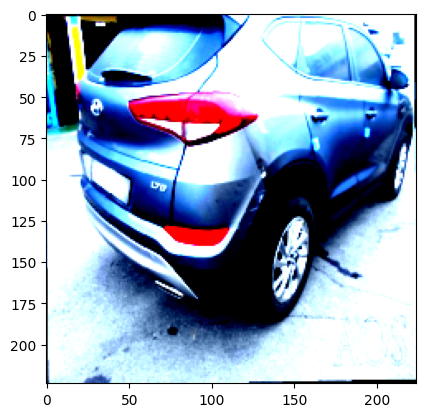

In [35]:
plt.imshow(images[0].permute(1,2,0))

### Model 1 : CNN 

In [41]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3,out_channels = 16,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (3,224,224) out = (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (16,112,112)
            nn.Conv2d(in_channels = 16,out_channels = 32,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (16,112,112) out = (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (32,56,56)
            nn.Conv2d(in_channels = 32,out_channels = 64,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (32,56,56) out = (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes) 
            
        )
    def forward(self,x):
        x = self.network(x)
        return x
        


In [42]:
# Initiate the model , loss function and Optimizer
model = CarClassifierCNN(num_classes= num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

In [43]:
images.size(0)

32

In [44]:
len(train_loader.dataset)

1725

In [49]:
def train_model(model,criterion,optimizer,epochs = 5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num,(images , labels) in enumerate(train_loader):
            images , labels = images.to(device),labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward Pass

            outputs = model(images)
            loss = criterion(outputs,labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            if (batch_num +1)% 10 ==0:
                print(f"Batch: {batch_num+1} , Epoch : {epoch +1} ,Loss : {loss.item():.2f}")
            

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch + 1}/{epochs}] , Avg Loss : {epoch_loss:.4f}")
    
        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels  = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images , labels = images.to(device),labels.to(device)
                outputs = model(images)
                _,predicted = torch.max(outputs.data , 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f" *** Validation Accuracy : {100 * correct/total:.2f}% ***")

    end = time.time()
    print(f"Execution Time : {end- start} seconds")
    return all_labels , all_predictions
                
            

In [51]:
all_labels , all_predictions = train_model(model,criterion , optimizer,epochs = 5)

Batch: 10 , Epoch : 1 ,Loss : 1.30
Batch: 20 , Epoch : 1 ,Loss : 1.13
Batch: 30 , Epoch : 1 ,Loss : 0.81
Batch: 40 , Epoch : 1 ,Loss : 1.24
Batch: 50 , Epoch : 1 ,Loss : 1.08
Epoch [1/5] , Avg Loss : 1.0352
 *** Validation Accuracy : 54.43% ***
Batch: 10 , Epoch : 2 ,Loss : 0.90
Batch: 20 , Epoch : 2 ,Loss : 1.02
Batch: 30 , Epoch : 2 ,Loss : 0.56
Batch: 40 , Epoch : 2 ,Loss : 0.94
Batch: 50 , Epoch : 2 ,Loss : 0.92
Epoch [2/5] , Avg Loss : 0.9735
 *** Validation Accuracy : 54.26% ***
Batch: 10 , Epoch : 3 ,Loss : 0.91
Batch: 20 , Epoch : 3 ,Loss : 0.87
Batch: 30 , Epoch : 3 ,Loss : 0.85
Batch: 40 , Epoch : 3 ,Loss : 1.10
Batch: 50 , Epoch : 3 ,Loss : 0.78
Epoch [3/5] , Avg Loss : 0.8653
 *** Validation Accuracy : 60.00% ***
Batch: 10 , Epoch : 4 ,Loss : 0.74
Batch: 20 , Epoch : 4 ,Loss : 0.90
Batch: 30 , Epoch : 4 ,Loss : 0.73
Batch: 40 , Epoch : 4 ,Loss : 0.71
Batch: 50 , Epoch : 4 ,Loss : 0.78
Epoch [4/5] , Avg Loss : 0.8084
 *** Validation Accuracy : 57.39% ***
Batch: 10 , Epoch : 

### Model 2 : CNN with regularization

In [52]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3,out_channels = 16,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (3,224,224) out = (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (16,112,112)
            nn.Conv2d(in_channels = 16,out_channels = 32,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (16,112,112) out = (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (32,56,56)
            nn.Conv2d(in_channels = 32,out_channels = 64,kernel_size = (3,3),stride = 1,padding = 1 ), # in = (32,56,56) out = (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = (2,2),stride = 2,padding = 0), # out  (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes) 
            
        )
    def forward(self,x):
        x = self.network(x)
        return x

In [53]:
model = CarClassifierCNNWithRegularization(num_classes= num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001,weight_decay = 1e-4)
all_labels , all_predictions = train_model(model,criterion , optimizer,epochs = 10)

Batch: 10 , Epoch : 1 ,Loss : 10.93
Batch: 20 , Epoch : 1 ,Loss : 6.75
Batch: 30 , Epoch : 1 ,Loss : 2.20
Batch: 40 , Epoch : 1 ,Loss : 1.32
Batch: 50 , Epoch : 1 ,Loss : 1.51
Epoch [1/10] , Avg Loss : 7.0408
 *** Validation Accuracy : 47.30% ***
Batch: 10 , Epoch : 2 ,Loss : 1.36
Batch: 20 , Epoch : 2 ,Loss : 1.52
Batch: 30 , Epoch : 2 ,Loss : 1.34
Batch: 40 , Epoch : 2 ,Loss : 1.52
Batch: 50 , Epoch : 2 ,Loss : 1.22
Epoch [2/10] , Avg Loss : 1.4419
 *** Validation Accuracy : 46.09% ***
Batch: 10 , Epoch : 3 ,Loss : 1.23
Batch: 20 , Epoch : 3 ,Loss : 1.51
Batch: 30 , Epoch : 3 ,Loss : 1.17
Batch: 40 , Epoch : 3 ,Loss : 1.34
Batch: 50 , Epoch : 3 ,Loss : 1.58
Epoch [3/10] , Avg Loss : 1.3784
 *** Validation Accuracy : 48.00% ***
Batch: 10 , Epoch : 4 ,Loss : 1.36
Batch: 20 , Epoch : 4 ,Loss : 1.30
Batch: 30 , Epoch : 4 ,Loss : 1.22
Batch: 40 , Epoch : 4 ,Loss : 1.25
Batch: 50 , Epoch : 4 ,Loss : 1.21
Epoch [4/10] , Avg Loss : 1.3549
 *** Validation Accuracy : 47.83% ***
Batch: 10 , Epo

### Model 3 Transfer Learning with EfficientNet

In [55]:
model = models.efficientnet_b0(weights = 'DEFAULT')
model.classifier[1].in_features

1280

In [57]:

class CarClassifierEfficientNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights = 'DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        x = self.model(x)
        return x

In [ ]:
model = CarClassifierEfficientNet(num_classes= num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad ,model.parameters()),lr = 0.001)
all_labels , all_predictions = train_model(model,criterion , optimizer,epochs = 10)

Batch: 10 , Epoch : 1 ,Loss : 1.70
Batch: 20 , Epoch : 1 ,Loss : 1.68


### Model 4 Transfer Learning with ResNet

In [ ]:
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        

        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features,num_classes)
        )

    def forward(self,x):
        x = self.model(x)
        return x

In [ ]:
model = CarClassifierResNet(num_classes= num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad ,model.parameters()),lr = 0.001)
all_labels , all_predictions = train_model(model,criterion , optimizer,epochs = 10)